In [1]:
import pandas as pd
dataset=pd.read_csv("Tatacoffee13_21.csv", parse_dates=['Date'], index_col='Date')

In [2]:
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [3]:
# start date and end date
from datetime import date, timedelta
import pandas as pd
start_date=pd.to_datetime("2013-01-01")
# Here timedelta is used to subtract one day from the given date and the result is stored in end_date (i.e "2019-02-03")
end_date = pd.to_datetime("2019-02-04") - timedelta(days=1) # excluding last
# here we are getting the dates in sequence from 2013-01-01 to 2019-02-03
# here freq='d' means daily, every day from start_date to end_date got generated
all_date=pd.date_range(start_date,end_date,freq='d')

In [4]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[ns]', length=2225, freq='D')

In [5]:
# copying the dataset to dummyDate
dummyDate=dataset

In [6]:
# now changing the dates in the dummyDate using all_date values
dummyDate.index = all_date

In [7]:
# now the dates are in sequence in the dataset
dummyDate

,Open,High,Low,Close
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-05,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2019-01-30,202.90,207.80,201.35,205.00
2019-01-31,206.00,206.85,202.05,202.95
2019-02-01,203.90,203.90,199.35,201.00
2019-02-02,200.00,222.00,196.00,218.35


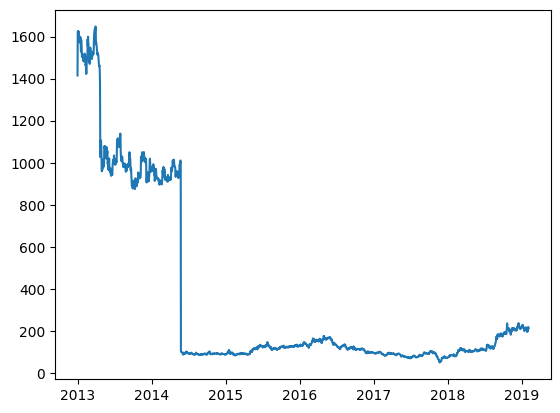

In [8]:
import matplotlib.pyplot as plt
plt.plot(dataset["Close"])

<Figure size 1600x500 with 0 Axes>

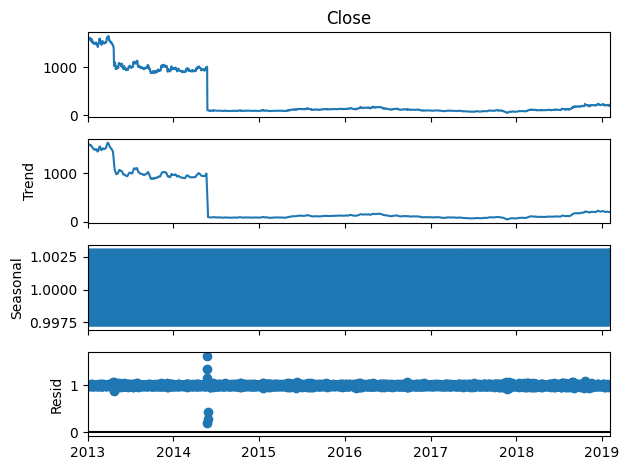

In [9]:
# to breakdown the time into three parts : trend, seasonal and residual
# trend : shows longterm direction of the data
# Seasonal : shows patterns that repeat at regular intervals
# residual : remaining random fluctuations after removing the trend and seasonal components
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(dummyDate["Close"], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

<Figure size 1600x500 with 0 Axes>

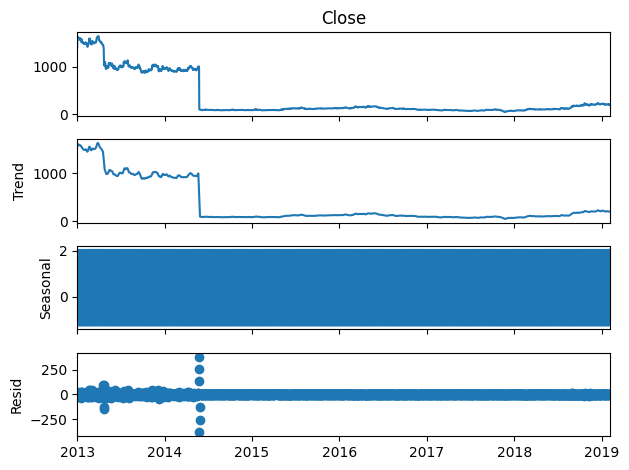

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(dummyDate["Close"], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

In [12]:
# to check whether the time series is stationary or not using Augmented Dickey fuller test
from statsmodels.tsa.stattools import adfuller
# function to determine the stationarity
# passing timeseries, dataframe and pollutant for OHLC input
def adf_test(timeseries,df,pollutant):
# plot the data in the figure which has width of 16 inches and height of 5 inches
   plt.figure(figsize=(16,5))
   from statsmodels.tsa.stattools import adfuller
   # Heading to print the results 
   print("Results of Dickey-Fuller Test")
   # To run the Augmented Dickey Fuller test, we pass the timeseries(dataset) and autolag as "AIC" to the adfuller method
   
   dftest=adfuller(timeseries, autolag='AIC')
    # The result of the test is a tuple which contain 5 values so it is converted to series and stored in dfoutput
   dfoutput=pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    # finding percentages(1,5,10) of critical value for each value in the dfoutput
   for key, value in dftest[4].items():
       dfoutput['Critical Value (%s)' %key] = value
   # display the output of the ADF test    
   print(dfoutput)
    # stores the test output to another variable "ans"
   ans=dfoutput
    # Printing the condition for alternate and null hypothesis
   print("Condition")
   print("p-value<=0.05--> Accept alternate hypothesis")
   print("p-value>0.05--> Accept null hypothesis")
    # Condition to accept alternate hypothesis is given  in the if clause
    # if value of Test statistic is less than any of the critical value (i.e 1%, 5%, 10%) and p-value is less than 0.05 then accept the alternate hypothesis
    # i.e the time series is stationary
   if(ans['Test Statistic']<ans["Critical Value (1%)"] or ans['Test Statistic']<ans["Critical Value (5%)"] or ans["Test Statistic"]<ans["Critical Value (10%)"] and ans["p-value"]<=0.05):
      print("Condition:statistic < any critical value and p-value<0.05 to reject null hypothesis")
      print("Reject null hypothesis : Stationarity")
      print("Accept Alternate hypothesis :Stationarity")
      message="Stationariry based on ADH"
   # if the if clause fails then else clause will be executed i.e accepting null hypothesis
    # as the value of test statistic might be greater than all the critical value and p-value is greater than 0.05 
    # time series is non-stationary
   else:
       print("Condition: statistic > all critical value and p-value > 0.05 to accept null hypothiesis")
       print("Accept null hypothesis: Non Statinarity")
       print("Reject alternate hypothesis : Non Stationarity")
       message="Non-Stationarity based on ADH"

   # plot the values over time    
   plt.plot(df.index, df[pollutant], label=pollutant)
   plt.legend(loc='best')
   # display the title based on the stationary output and the parameter passed(here it is Close) 
   plt.title("{}_{}_2013 to 2021".format(message,pollutant))
    # to save the graph in the given format
   plt.savefig("{}_ADH.png".format(pollutant))
   plt.show()
    # return message with respect to stationary or non stationary displayed based on the time series passed
   return message
# Call the function and run the test


Results of Dickey-Fuller Test
Test Statistic                   -3.007236
p-value                           0.034224
#Lags Used                        1.000000
Number of Observations Used    2223.000000
Critical Value (1%)              -3.433295
Critical Value (5%)              -2.862841
Critical Value (10%)             -2.567463
dtype: float64
Condition
p-value<=0.05--> Accept alternate hypothesis
p-value>0.05--> Accept null hypothesis
Condition:statistic < any critical value and p-value<0.05 to reject null hypothesis
Reject null hypothesis : Stationarity
Accept Alternate hypothesis :Stationarity


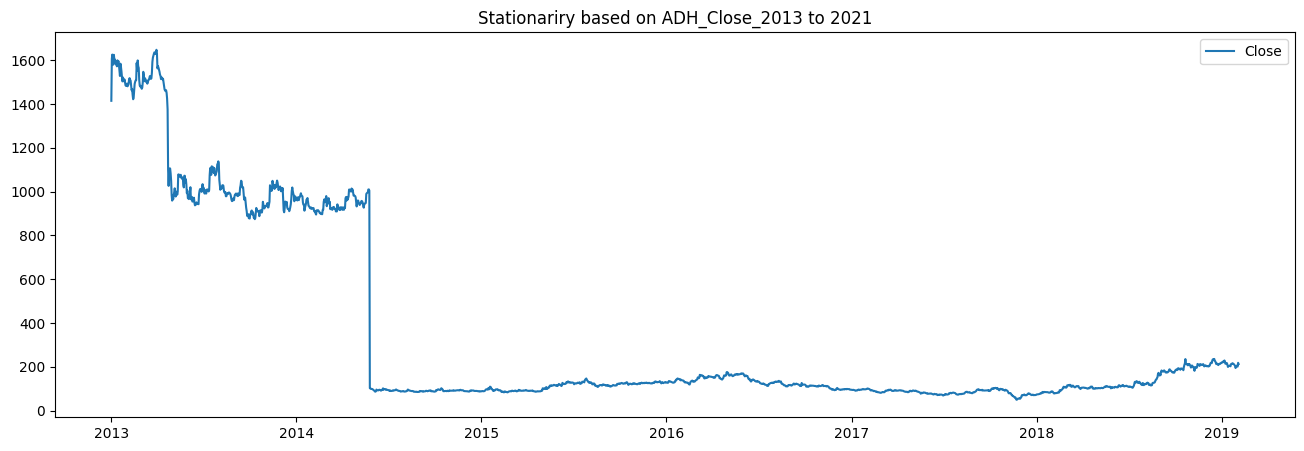

'Stationariry based on ADH'

In [13]:
adf_test(dataset["Close"],dataset,"Close")